In [2]:
import scanpy as sc
from pathlib import Path

BASE  = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
adata = sc.read_h5ad(
    BASE / "macrophage_annotation/Macrophage_Atlas_FINAL_v3_CLEAN_ANNOTATED.h5ad"
)

CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",  # blue — circulating precursors
    "Differentiating / Transitional":    "#76B7B2",  # teal — transitional state
    "Scavenging / C1q+ Macrophages":     "#59A14F",  # green — homeostatic
    "Resident / Quiescent Macrophages":  "#B07AA1",  # purple — deep quiescence
    "Inflammatory Macrophages":          "#E15759",  # red — active inflammation
    "Lipid-Stressed / Foam Cells":       "#F28E2B",  # orange — lipid stress
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",  # brown — terminal disease
}

print("obsm keys:", list(adata.obsm.keys()))
print("uns keys:",  list(adata.uns.keys()))

obsm keys: ['X_scanorama', 'X_umap']
uns keys: ['batch_colors', 'cell_type_meta_sizes', 'hvg', 'leiden_0_1', 'leiden_0_2', 'leiden_0_3', 'leiden_0_4', 'leiden_0_5', 'leiden_0_6', 'leiden_0_7', 'leiden_0_8', 'leiden_0_9', 'leiden_1_0', 'neighbors', 'paga', 'rank_genes_groups', 'umap']


Cells: 81633  Genes: 23496

Computing pre-integration UMAP from raw counts...
  Normalizing...
  HVG selection...
  PCA...
  Neighbors + UMAP (pre-integration)...


2026-03-17 10:55:51.010351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773741351.208429  541638 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773741351.369075  541638 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773741352.134179  541638 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773741352.134241  541638 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773741352.134245  541638 computation_placer.cc:177] computation placer alr

  Pre-integration UMAP done.

Plotting before/after integration...


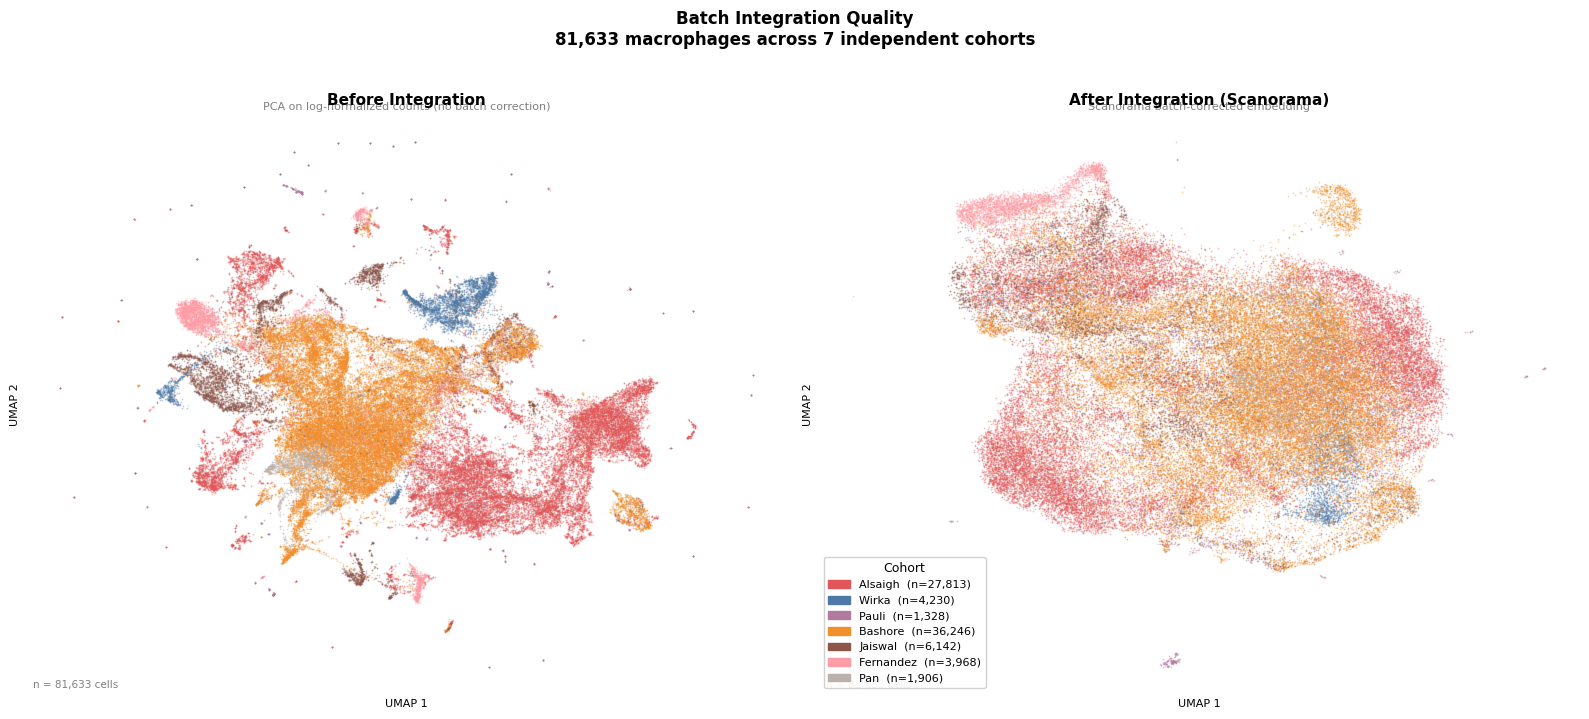

Saved: fig1_before_after_integration

Plotting meta-cluster UMAP (v3)...


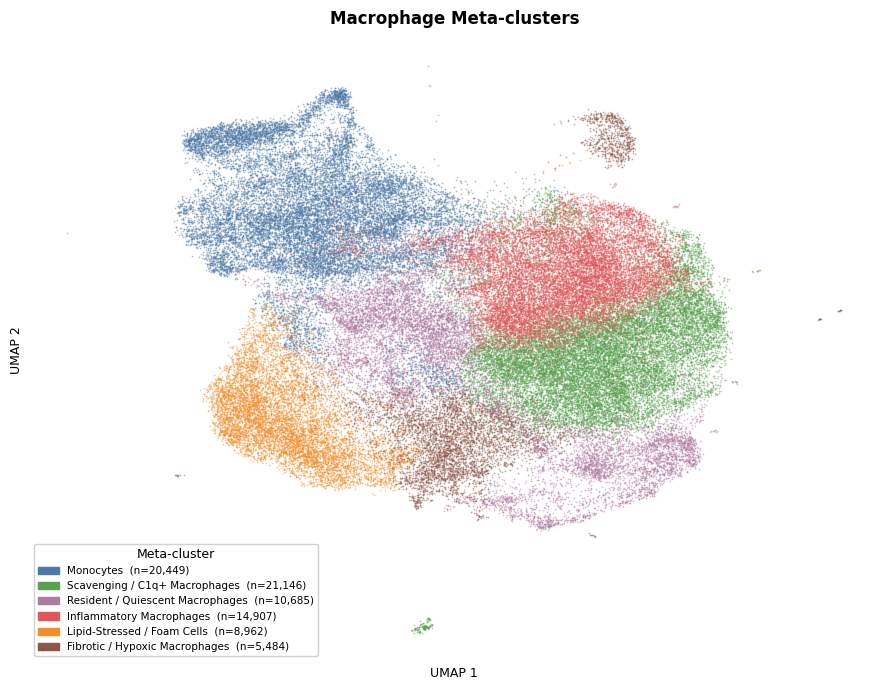

Saved: fig1_metaclusters_umap

All figures saved to: /storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure1


In [3]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import gc
import warnings
warnings.filterwarnings("ignore")

BASE    = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OUT_DIR = BASE / "figures/figure1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

COHORT_COLORS = {
    "alsaigh":   "#E15759",
    "wirka":     "#4E79A7",
    "pauli":     "#B07AA1",
    "bashore":   "#F28E2B",
    "jaiswal":   "#8C564B",
    "fernandez": "#FF9DA7",
    "pan":       "#BAB0AC",
}

CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",
    # "Differentiating / Transitional":  removed — merged into Monocytes (v3)
    "Scavenging / C1q+ Macrophages":     "#59A14F",
    "Resident / Quiescent Macrophages":  "#B07AA1",
    "Inflammatory Macrophages":          "#E15759",
    "Lipid-Stressed / Foam Cells":       "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",
}

# Store post-integration UMAP and metadata before we do anything
umap_integrated = adata.obsm["X_umap"].copy()
cell_types       = adata.obs["cell_type_meta_v3"].copy()   # <-- v3
batches          = adata.obs["batch"].copy()

print(f"Cells: {adata.n_obs}  Genes: {adata.n_vars}")

# ── COMPUTE PRE-INTEGRATION UMAP ──────────────────────────────────
print("\nComputing pre-integration UMAP from raw counts...")

adata_pre = sc.AnnData(
    X   = adata.layers["counts"].copy(),
    obs = adata.obs[["batch", "cell_type_meta_v3"]].copy(),   # <-- v3
    var = adata.var.copy(),
)
adata_pre.obs["batch"]             = batches.values
adata_pre.obs["cell_type_meta_v3"] = cell_types.values        # <-- v3

# Standard preprocessing
print("  Normalizing...")
sc.pp.normalize_total(adata_pre, target_sum=1e4)
sc.pp.log1p(adata_pre)

print("  HVG selection...")
sc.pp.highly_variable_genes(
    adata_pre,
    n_top_genes=2000,
    batch_key="batch",
)
adata_pre = adata_pre[:, adata_pre.var["highly_variable"]].copy()

print("  PCA...")
sc.pp.scale(adata_pre, max_value=10)
sc.tl.pca(adata_pre, n_comps=50, svd_solver="arpack")

print("  Neighbors + UMAP (pre-integration)...")
sc.pp.neighbors(adata_pre, n_pcs=50, n_neighbors=15)
sc.tl.umap(adata_pre, min_dist=0.3)

umap_pre = adata_pre.obsm["X_umap"].copy()
print("  Pre-integration UMAP done.")

del adata_pre
gc.collect()

# ── PLOTTING FUNCTION ─────────────────────────────────────────────
def plot_umap(ax, umap_coords, color_col, color_dict,
              title, subtitle=None, point_size=1.5, alpha=0.4):

    ax.set_facecolor("white")

    for group, color in color_dict.items():
        mask = color_col == group
        if mask.sum() == 0:
            continue
        ax.scatter(
            umap_coords[mask, 0],
            umap_coords[mask, 1],
            c=color,
            s=point_size,
            alpha=alpha,
            linewidths=0,
            rasterized=True,
            zorder=2,
        )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    if subtitle:
        ax.text(0.5, 1.01, subtitle, transform=ax.transAxes,
                ha="center", fontsize=8, color="gray")
    ax.set_xlabel("UMAP 1", fontsize=8)
    ax.set_ylabel("UMAP 2", fontsize=8)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)


# ── FIGURE 1 — Before vs After integration ───────────────────────
print("\nPlotting before/after integration...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_umap(
    axes[0], umap_pre, batches, COHORT_COLORS,
    title="Before Integration",
    subtitle="PCA on log-normalized counts (no batch correction)",
)

plot_umap(
    axes[1], umap_integrated, batches, COHORT_COLORS,
    title="After Integration (Scanorama)",
    subtitle="Scanorama batch-corrected embedding",
)

legend_handles = [
    mpatches.Patch(
        color=COHORT_COLORS[c],
        label=f"{c.capitalize()}  (n={(batches==c).sum():,})"
    )
    for c in COHORT_COLORS
    if (batches == c).sum() > 0
]

axes[1].legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=8,
    framealpha=0.9,
    title="Cohort",
    title_fontsize=9,
)

for ax in axes:
    ax.text(0.01, 0.01, f"n = {len(batches):,} cells",
            transform=ax.transAxes, fontsize=7.5, color="gray")

fig.suptitle(
    "Batch Integration Quality\n"
    "81,633 macrophages across 7 independent cohorts",
    fontsize=12, fontweight="bold", y=1.02
)

plt.tight_layout()
fig.savefig(OUT_DIR / "fig1_before_after_integration.pdf",
            dpi=300, bbox_inches="tight")
fig.savefig(OUT_DIR / "fig1_before_after_integration.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig1_before_after_integration")


# ── FIGURE 2 — Meta-clusters (post-integration, v3) ──────────────
print("\nPlotting meta-cluster UMAP (v3)...")

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.set_facecolor("white")

for cluster, color in CLUSTER_COLORS.items():
    mask = cell_types == cluster
    if mask.sum() == 0:
        continue
    ax.scatter(
        umap_integrated[mask, 0],
        umap_integrated[mask, 1],
        c=color,
        s=1.5,
        alpha=0.5,
        linewidths=0,
        rasterized=True,
        zorder=2,
    )

legend_handles = [
    mpatches.Patch(
        color=CLUSTER_COLORS[cl],
        label=f"{cl}  (n={(cell_types==cl).sum():,})"
    )
    for cl in CLUSTER_COLORS
    if (cell_types == cl).sum() > 0
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=7.5,
    framealpha=0.9,
    title="Meta-cluster",
    title_fontsize=9,
    markerscale=2,
)

ax.set_title(
    "Macrophage Meta-clusters",
    fontsize=12, fontweight="bold", pad=10
)
ax.set_xlabel("UMAP 1", fontsize=9)
ax.set_ylabel("UMAP 2", fontsize=9)
ax.tick_params(left=False, bottom=False,
               labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.text(0.01, 0.01, f"n = {len(cell_types):,} cells",
        transform=ax.transAxes, fontsize=8, color="gray")

plt.tight_layout()
fig.savefig(OUT_DIR / "fig1_metaclusters_umap.pdf",
            dpi=300, bbox_inches="tight")
fig.savefig(OUT_DIR / "fig1_metaclusters_umap.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig1_metaclusters_umap")

print("\nAll figures saved to:", OUT_DIR)

In [5]:
# ── FIGURE 3 — Original cell types before meta-clustering ─────────
print("\nPlotting original cell types UMAP...")

# Check which original cell type column to use
print("Available cell type columns:")
for col in ["cell_type_original", "cell_type_final", 
            "cell_type_meta", "cell_type_final_v2"]:
    if col in adata.obs.columns:
        print(f"  {col}: {adata.obs[col].nunique()} unique values")
        print(f"    {adata.obs[col].value_counts().head(5).to_dict()}")


Plotting original cell types UMAP...
Available cell type columns:
  cell_type_original: 13 unique values
    {'Inflammatory Macrophages (CCL3+ / MHC-II)': 13567, 'Lipid-Scavenging Macrophages (MSR1+ / C1q+)': 12308, 'Classical Monocytes (S100A+ Inflammatory)': 11770, 'Fibrotic Foam Cells (SPP1+ / FABP5+)': 8962, ' Homeostatic Lipid-Regulating Macrophages (APOE+/ SELENOP+)': 8717}
  cell_type_final: 17 unique values
    {'Classical Monocytes (S100A+ Inflammatory)': 11770, 'Fibrotic Foam Cells (SPP1+ / FABP5+)': 9017, 'Inflammatory Macrophages (CCL3+ / MHC-II)': 8914, ' Homeostatic Lipid-Regulating Macrophages (APOE+/ SELENOP+)': 8717, 'Quiescent Resident Macrophages (ZEB2+ / NEAT1+)': 5995}
  cell_type_meta: 7 unique values
    {'Inflammatory': 22125, 'Monocyte Progenitors': 16747, 'LAM / C1q+ Axis': 16741, 'Foam Cell / Lipid-Stressed': 9017, 'Resident / Homeostatic': 7817}
  cell_type_final_v2: 13 unique values
    {'Inflammatory Macrophages (CCL3+ / MHC-II)': 13567, 'Lipid-Scavenging

In [6]:
# Uses umap_integrated, cell_types, batches already in memory
# Only needs adata.obs for the original cell type column

original_types = adata.obs["cell_type_final_v2"].copy()

# 13 colors — visually distinct, grouped by meta-cluster logic
ORIGINAL_COLORS = {
    # Monocytes — blues
    "Classical Monocytes (S100A8+ / FCN1+)":                    "#2171B5",
    "Intermediate / Non-Classical Monocytes (LST1+ / S100A4+)": "#6BAED6",
    # Differentiating — teal
    "Transitional Monocytes (VCAN+ / ZEB2+ Differentiating)":   "#76B7B2",
    # Scavenging — greens
    "Homeostatic Lipid-Regulating Macrophages (APOE+ / SELENOP+)": "#41AB5D",
    "Lipid-Scavenging Macrophages (C1q+ / HLA-DR+)":            "#74C476",
    "Terminal LAMs (GPNMB+ / LIPA+)":                           "#C7E9C0",
    # Resident — purples
    "Quiescent Resident Macrophages (ZEB2+ / NEAT1+)":          "#6A51A3",
    "Iron-Rich Macrophages (FTL+ / APOE+)":                     "#9E9AC8",
    "Resident Perivascular Macrophages (LYVE1+ / FOLR2+)":      "#DADAEB",
    # Inflammatory — reds
    "Inflammatory Macrophages (CCL3+ / MHC-II)":                "#CB181D",
    "Interferon-Inducible Macrophages (ISG15+ / IFI6+)":        "#FB6A4A",
    # Foam — orange
    "Lipid-Stressed Foam Cells (FABP5+ / CSTB+)":               "#F28E2B",
    # Fibrotic — brown
    "Fibrotic Macrophages (SPP1+ / FN1+ Hypoxic)":              "#8C564B",
}

print("Cell types found in data:")
for ct in original_types.unique():
    print(f"  '{ct}'")

Cell types found in data:
  'Lipid-Stressed Foam Cells (FABP5+ / CSTB+)'
  'Inflammatory Macrophages (CCL3+ / MHC-II)'
  'Classical Monocytes (S100A8+ / FCN1+)'
  'Homeostatic Lipid-Regulating Macrophages (APOE+ / SELENOP+)'
  'Fibrotic Macrophages (SPP1+ / FN1+ Hypoxic)'
  'Quiescent Resident Macrophages (ZEB2+ / NEAT1+)'
  'Iron-Rich Macrophages (FTL+ / APOE+)'
  'Lipid-Scavenging Macrophages (C1q+ / HLA-DR+)'
  'Intermediate / Non-Classical Monocytes (LST1+ / S100A4+)'
  'Transitional Monocytes (VCAN+ / ZEB2+ Differentiating)'
  'Interferon-Inducible Macrophages (ISG15+ / IFI6+)'
  'Resident Perivascular Macrophages (LYVE1+ / FOLR2+)'
  'Terminal LAMs (GPNMB+ / LIPA+)'


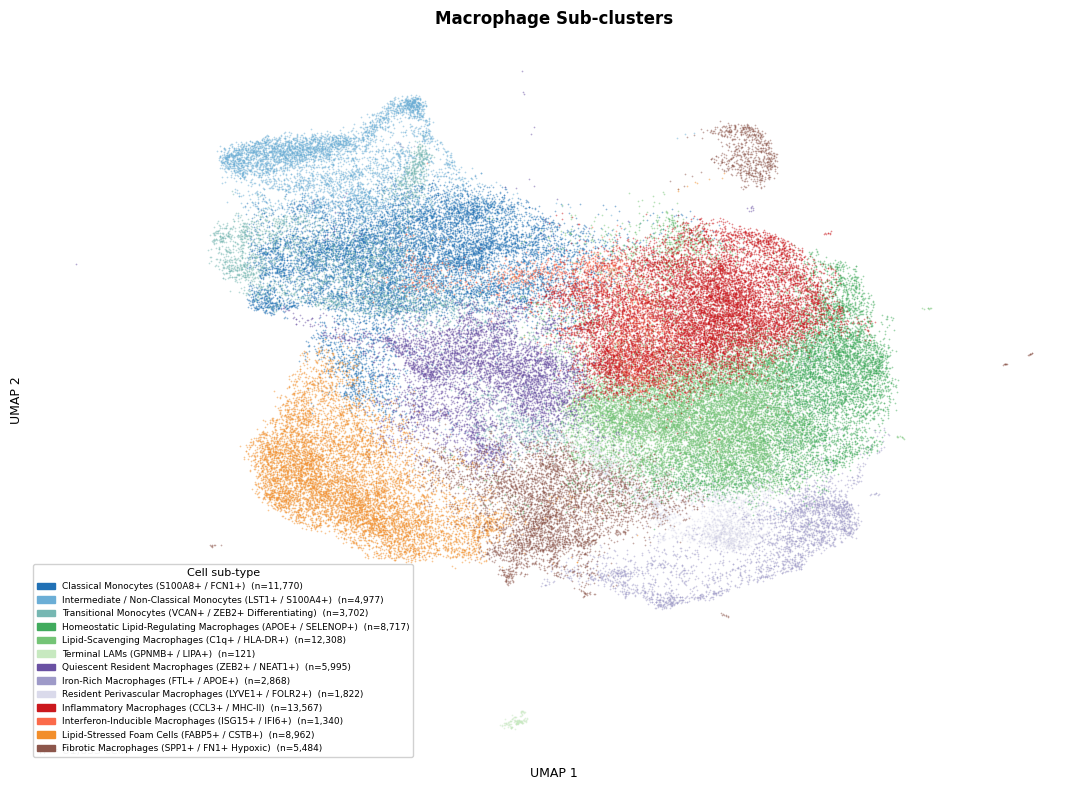

Saved: fig1_subclusters_umap


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ORIGINAL_COLORS = {
    # Monocytes — blues
    "Classical Monocytes (S100A8+ / FCN1+)":                       "#2171B5",
    "Intermediate / Non-Classical Monocytes (LST1+ / S100A4+)":    "#6BAED6",
    # Differentiating — teal
    "Transitional Monocytes (VCAN+ / ZEB2+ Differentiating)":      "#76B7B2",
    # Scavenging — greens
    "Homeostatic Lipid-Regulating Macrophages (APOE+ / SELENOP+)": "#41AB5D",
    "Lipid-Scavenging Macrophages (C1q+ / HLA-DR+)":               "#74C476",
    "Terminal LAMs (GPNMB+ / LIPA+)":                              "#C7E9C0",
    # Resident — purples
    "Quiescent Resident Macrophages (ZEB2+ / NEAT1+)":             "#6A51A3",
    "Iron-Rich Macrophages (FTL+ / APOE+)":                        "#9E9AC8",
    "Resident Perivascular Macrophages (LYVE1+ / FOLR2+)":         "#DADAEB",
    # Inflammatory — reds
    "Inflammatory Macrophages (CCL3+ / MHC-II)":                   "#CB181D",
    "Interferon-Inducible Macrophages (ISG15+ / IFI6+)":           "#FB6A4A",
    # Foam — orange
    "Lipid-Stressed Foam Cells (FABP5+ / CSTB+)":                  "#F28E2B",
    # Fibrotic — brown
    "Fibrotic Macrophages (SPP1+ / FN1+ Hypoxic)":                 "#8C564B",
}

fig, ax = plt.subplots(1, 1, figsize=(11, 8))
ax.set_facecolor("white")

for ct, color in ORIGINAL_COLORS.items():
    mask = original_types == ct
    if mask.sum() == 0:
        continue
    ax.scatter(
        umap_integrated[mask, 0],
        umap_integrated[mask, 1],
        c=color,
        s=1.5,
        alpha=0.5,
        linewidths=0,
        rasterized=True,
        zorder=2,
    )

# Legend with cell counts — grouped by meta-cluster
legend_handles = [
    mpatches.Patch(
        color=ORIGINAL_COLORS[ct],
        label=f"{ct}  (n={(original_types==ct).sum():,})"
    )
    for ct in ORIGINAL_COLORS
    if (original_types == ct).sum() > 0
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=6.5,
    framealpha=0.9,
    title="Cell sub-type",
    title_fontsize=8,
    markerscale=2,
    ncol=1,
)

ax.set_title(
    "Macrophage Sub-clusters",
    fontsize=12, fontweight="bold", pad=10
)
ax.set_xlabel("UMAP 1", fontsize=9)
ax.set_ylabel("UMAP 2", fontsize=9)
ax.tick_params(left=False, bottom=False,
               labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.text(0.01, 0.01, f"n = {len(original_types):,} cells",
        transform=ax.transAxes, fontsize=8, color="gray")

plt.tight_layout()
fig.savefig(OUT_DIR / "fig1_subclusters_umap.pdf",
            dpi=300, bbox_inches="tight")
fig.savefig(OUT_DIR / "fig1_subclusters_umap.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig1_subclusters_umap")

/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/_utils/__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2073: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, An

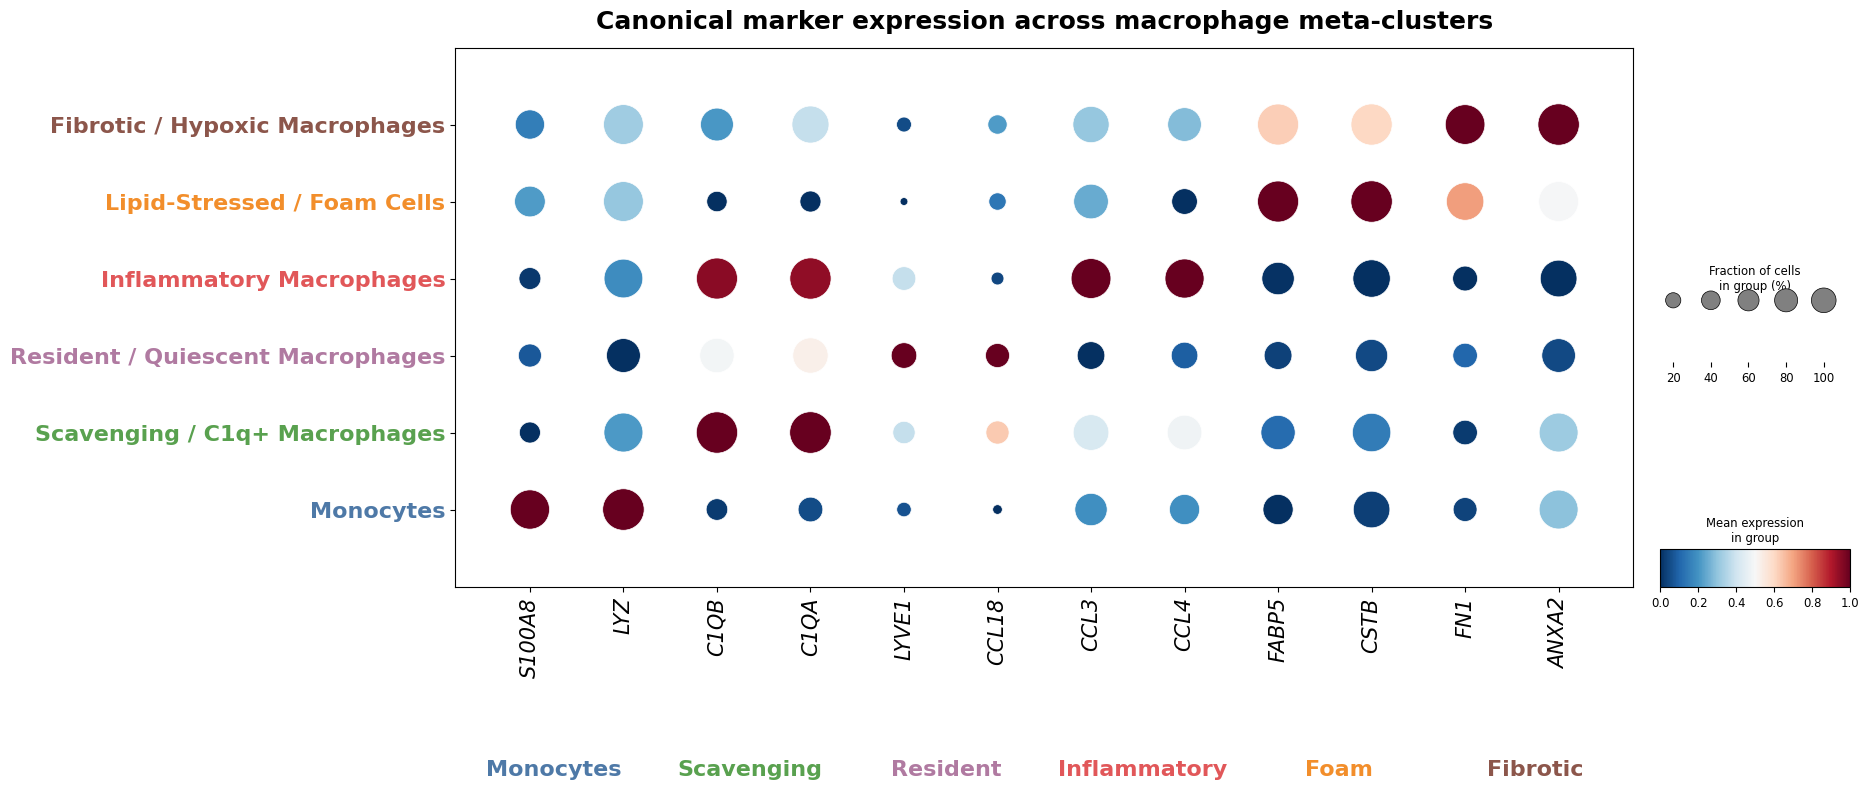

Saved: fig1E_dotplot_metaclusters


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE  = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
adata = sc.read_h5ad(
    BASE / "macrophage_annotation/Macrophage_Atlas_FINAL_v3_CLEAN_ANNOTATED.h5ad"
)

CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",
    "Scavenging / C1q+ Macrophages":     "#59A14F",
    "Resident / Quiescent Macrophages":  "#B07AA1",
    "Inflammatory Macrophages":          "#E15759",
    "Lipid-Stressed / Foam Cells":       "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",
}

OUT_DIR = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MARKERS_FINAL = [
    "S100A8", "LYZ",
    "C1QB", "C1QA",
    "LYVE1", "CCL18",
    "CCL3", "CCL4",
    "FABP5", "CSTB",
    "FN1", "ANXA2",
]

CLUSTER_ORDER = [
    "Monocytes",
    "Scavenging / C1q+ Macrophages",
    "Resident / Quiescent Macrophages",
    "Inflammatory Macrophages",
    "Lipid-Stressed / Foam Cells",
    "Fibrotic / Hypoxic Macrophages",
]

MARKER_GROUPS = {
    "Monocytes":    ["S100A8", "LYZ"],
    "Scavenging":   ["C1QB", "C1QA"],
    "Resident":     ["LYVE1", "CCL18"],
    "Inflammatory": ["CCL3", "CCL4"],
    "Foam":         ["FABP5", "CSTB"],
    "Fibrotic":     ["FN1", "ANXA2"],
}

# ── SET CLUSTER ORDER REVERSED ────────────────────────────────────
adata.obs["cell_type_meta_v2"] = pd.Categorical(
    adata.obs["cell_type_meta_v2"],
    categories=CLUSTER_ORDER[::-1],
    ordered=True,
)

markers_present = [g for g in MARKERS_FINAL if g in adata.var_names]

# ── DOTPLOT ───────────────────────────────────────────────────────
dp = sc.pl.dotplot(
    adata,
    var_names=markers_present,
    groupby="cell_type_meta_v2",
    standard_scale="var",
    colorbar_title="Mean expression\n(scaled 0-1)",
    size_title="% expressing",
    color_map="RdBu_r",
    figsize=(18, 7),
    show=False,
    return_fig=True,
)

dp.style(
    dot_edge_color="white",
    dot_edge_lw=0.5,
    grid=False,
    dot_min=0.0,
    dot_max=1.0,
    size_exponent=0.6,
    largest_dot=900,
)

# Wider legend area gives room for the bigger dots
dp.legend(width=2.5)

axes_dict  = dp.get_axes()
dot_ax     = axes_dict["mainplot_ax"]
n_clusters = len(CLUSTER_ORDER)
n_genes    = len(markers_present)

# ── FIX LEGEND DOT OVERLAP ───────────────────────────────────────
# Shrink size-legend dots independently of the matrix dots
size_legend_ax = axes_dict.get("size_legend_ax")
if size_legend_ax is not None:
    for coll in size_legend_ax.collections:
        sizes = coll.get_sizes()
        coll.set_sizes(sizes * 0.35)

# ── BIGGER FONT FOR ALL TICK LABELS ──────────────────────────────
dot_ax.tick_params(axis="x", labelsize=16)
dot_ax.tick_params(axis="y", labelsize=16)

# ── COLOR Y-AXIS LABELS ──────────────────────────────────────────
for tick in dot_ax.get_yticklabels():
    label = tick.get_text()
    tick.set_color(CLUSTER_COLORS.get(label, "black"))
    tick.set_fontweight("bold")
    tick.set_fontsize(16)

# ── X-AXIS GENE LABELS — italic, bigger ──────────────────────────
for tick in dot_ax.get_xticklabels():
    tick.set_fontstyle("italic")
    tick.set_fontsize(15)

# ── GROUP LABELS — bigger ────────────────────────────────────────
group_sizes  = [2, 2, 2, 2, 2, 2]
group_names  = list(MARKER_GROUPS.keys())
group_colors = [CLUSTER_COLORS[c] for c in CLUSTER_ORDER]

cumsum = 0
for i, (name, size, color) in enumerate(
        zip(group_names, group_sizes, group_colors)):
    center_data = cumsum + size / 2 - 0.5
    x_frac = (center_data + 0.5) / n_genes
    dot_ax.text(
        x_frac, -0.32,
        name,
        ha="center", va="top",
        fontsize=16,
        fontweight="bold",
        color=color,
        transform=dot_ax.transAxes,
    )
    cumsum += size

# ── TITLE ─────────────────────────────────────────────────────────
dot_ax.set_title(
    "Canonical marker expression across macrophage meta-clusters",
    fontsize=18,
    fontweight="bold",
    pad=14,
)

# ── SAVE ──────────────────────────────────────────────────────────
plt.savefig(
    OUT_DIR / "fig1E_dotplot_metaclusters.pdf",
    dpi=300, bbox_inches="tight",
)
plt.savefig(
    OUT_DIR / "fig1E_dotplot_metaclusters.png",
    dpi=300, bbox_inches="tight",
)
plt.show()
plt.close()
print("Saved: fig1E_dotplot_metaclusters")

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE  = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
adata = sc.read_h5ad(
    BASE / "macrophage_annotation/Macrophage_Atlas_FINAL_v3_CLEAN_ANNOTATED.h5ad"
)

OUT_DIR = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MARKERS_FINAL = [
    "S100A8", "LYZ",        # Monocytes
    "C1QB",   "C1QA",       # Scavenging
    "CCL3",   "CCL4",       # Inflammatory
    "FABP5",  "CSTB",       # Foam
       "FN1",  "ANXA2",       # Fibrotic
    "LYVE1",  "CCL18",      # Resident
]

CLUSTER_ORDER = [
    "Monocytes",
    "Scavenging / C1q+ Macrophages",
    "Inflammatory Macrophages",
    "Lipid-Stressed / Foam Cells",
    "Fibrotic / Hypoxic Macrophages",
    "Resident / Quiescent Macrophages",
]

CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",
    "Scavenging / C1q+ Macrophages":     "#59A14F",
    "Inflammatory Macrophages":          "#E15759",
    "Lipid-Stressed / Foam Cells":       "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",
    "Resident / Quiescent Macrophages":  "#B07AA1",
}

MARKER_GROUPS = {
    "Monocytes":    ["S100A8", "LYZ"],
    "Scavenging":   ["C1QB",   "C1QA"],
    "Inflammatory": ["CCL3",   "CCL4"],
    "Foam":         ["FABP5",  "CSTB"],
    "Fibrotic":     [   "FN1", "ANXA2"],
    "Resident":     ["LYVE1",  "CCL18"],
}

group_names  = list(MARKER_GROUPS.keys())
group_sizes  = [2] * 6
group_colors = [CLUSTER_COLORS[c] for c in CLUSTER_ORDER]

# ── Reorder categories ────────────────────────────────────────────
adata.obs["cell_type_meta_v3"] = pd.Categorical(
    adata.obs["cell_type_meta_v3"],
    categories=CLUSTER_ORDER[::-1],
    ordered=True,
)

markers_present = [g for g in MARKERS_FINAL if g in adata.var_names]
n_genes_total   = len(markers_present)

# ── DOTPLOT ───────────────────────────────────────────────────────
dp = sc.pl.dotplot(
    adata,
    var_names=markers_present,
    groupby="cell_type_meta_v3",
    standard_scale="var",
    colorbar_title="Mean expression\n(scaled 0-1)",
    size_title="% expressing",
    dot_max=0.8,
    dot_min=0.0,
    color_map="RdBu_r",
    figsize=(12, 5),
    show=False,
    return_fig=True,
)

dp.style(
    dot_edge_color="white",
    dot_edge_lw=0.5,
    grid=True,
)

axes_dict = dp.get_axes()
dot_ax    = axes_dict["mainplot_ax"]

# ── COLOR Y-AXIS LABELS ───────────────────────────────────────────
for tick in dot_ax.get_yticklabels():
    label = tick.get_text()
    tick.set_color(CLUSTER_COLORS.get(label, "black"))
    tick.set_fontweight("bold")
    tick.set_fontsize(9)

# ── VERTICAL SEPARATORS ───────────────────────────────────────────
cumsum = 0
for i, size in enumerate(group_sizes):
    if i > 0:
        dot_ax.axvline(
            cumsum - 0.5,
            color="#cccccc", lw=1,
            linestyle="--", zorder=5,
        )
    cumsum += size

# ── GROUP LABELS ON TOP — axes coordinates, properly centered ─────
cumsum = 0
for i, (name, size, color) in enumerate(
        zip(group_names, group_sizes, group_colors)):
    x_left   = cumsum / n_genes_total
    x_right  = (cumsum + size) / n_genes_total
    x_center = (x_left + x_right) / 2
    dot_ax.text(
        x_center, 1.06, name,
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
        color=color,
        transform=dot_ax.transAxes,
    )
    cumsum += size

dot_ax.set_title(
    "Canonical marker expression across macrophage meta-clusters",
    fontsize=11, fontweight="bold", pad=28,
)

# ── SAVE ──────────────────────────────────────────────────────────
plt.savefig(OUT_DIR / "fig1E_dotplot_metaclusters_v3.pdf", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "fig1E_dotplot_metaclusters_v3.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: fig1E_dotplot_metaclusters_v3")

# ── RESIDENT VIOLIN PANEL ─────────────────────────────────────────
print("\nGenerating Resident marker violin panel...")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
resident_color = CLUSTER_COLORS["Resident / Quiescent Macrophages"]

for ax, gene in zip(axes, ["LYVE1", "CCL18"]):
    data_per_cluster = []
    labels           = []
    colors           = []

    for cluster in CLUSTER_ORDER:
        mask = adata.obs["cell_type_meta_v3"].isin([cluster])
        x    = adata[mask, gene].X
        if hasattr(x, "toarray"):
            x = x.toarray().flatten()
        x_nonzero = x[x > 0]
        data_per_cluster.append(x_nonzero if len(x_nonzero) > 0 else np.array([0.0]))
        labels.append(cluster.split(" / ")[0][:12])
        colors.append(CLUSTER_COLORS[cluster])

    parts = ax.violinplot(
        data_per_cluster,
        positions=range(len(CLUSTER_ORDER)),
        showmedians=True, showextrema=False, widths=0.7,
    )

    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(1.5)

    res_idx = CLUSTER_ORDER.index("Resident / Quiescent Macrophages")
    mask_r  = adata.obs["cell_type_meta_v3"] == "Resident / Quiescent Macrophages"
    x_r     = adata[mask_r, gene].X
    if hasattr(x_r, "toarray"):
        x_r = x_r.toarray().flatten()
    pct = (x_r > 0).mean() * 100
    ax.text(
        res_idx, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1,
        f"{pct:.0f}%",
        ha="center", va="top", fontsize=8,
        color=resident_color, fontweight="bold",
    )

    ax.set_xticks(range(len(CLUSTER_ORDER)))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_title(gene, fontsize=10, fontweight="bold", color=resident_color)
    ax.set_ylabel("Expression (log-norm)", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvspan(res_idx - 0.4, res_idx + 0.4,
               color=resident_color, alpha=0.08, zorder=0)

fig.suptitle(
    "Resident / Quiescent Macrophage marker expression\n"
    "(non-zero cells shown — markers expressed in perivascular sub-population)",
    fontsize=9, fontweight="bold",
)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig1E_resident_markers_violin_v3.pdf", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "fig1E_resident_markers_violin_v3.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: fig1E_resident_markers_violin_v3")

/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2073: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


Saved: fig1E_dotplot_metaclusters_v3

Generating Resident marker violin panel...
Saved: fig1E_resident_markers_violin_v3
